In [1]:
# ノートブックの環境変数設定
%env DATA_ROOT /home/ryo52/LAIME/atmacup11

env: DATA_ROOT=/home/ryo52/LAIME/atmacup11


In [2]:
import os
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import japanize_matplotlib

import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import warnings
from contextlib import contextmanager
import time
from collections import defaultdict
import math

# PyTorch 関連
import torch
from torch import nn
from torch.utils import data
from torchvision import transforms as T
from torch.optim import Adam
from torch.optim.optimizer import Optimizer

# CV と評価
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error

# モデル (timm) とロギング (wandb)
import timm
import wandb

# 警告を非表示に
warnings.filterwarnings('ignore')

# ノートブックで使われていたvivid.utils.timerの代替
@contextmanager
def timer(prefix=""):
    start = time.time()
    yield
    end = time.time()
    print(f"[{prefix}] {end - start:.2f} sec")

print(f"PyTorch Version: {torch.__version__}")
print(f"timm Version: {timm.__version__}")

/home/ryo52/miniconda3/envs/data_analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version: 2.9.0+cu128
timm Version: 1.0.22


In [3]:
# ---------------------------------
# ディレクトリ設定 (ノートブックの構成を流用)
# ---------------------------------

dataset_root = os.environ.get('DATA_ROOT', './atmacup11') # 環境変数がなければカレント配下を想定

input_dir = os.path.join(dataset_root, "inputs")
photo_dir = os.path.join(input_dir, "photos")

# このベースライン用の出力ディレクトリ
output_dir = os.path.join(dataset_root, "outputs_baseline_resnet18d")
os.makedirs(output_dir, exist_ok=True)

print(f"Input Dir: {input_dir}")
print(f"Output Dir: {output_dir}")

# ---------------------------------
# デバイス設定 (ノートブックの構成を流用)
# ---------------------------------
assert torch.cuda.is_available()
DEVICE = torch.device("cuda")
print(f"DEVICE: {DEVICE}")

Input Dir: /home/ryo52/LAIME/atmacup11/inputs
Output Dir: /home/ryo52/LAIME/atmacup11/outputs_baseline_resnet18d
DEVICE: cuda


In [4]:
train_df = pd.read_csv(os.path.join(input_dir, 'train.csv'))
test_df = pd.read_csv(os.path.join(input_dir, 'test.csv'))
submission_df = pd.read_csv(os.path.join(input_dir, 'atmaCup#11_sample_submission.csv'))

print(f"train_df: {train_df.shape}")
print(f"test_df: {test_df.shape}")
train_df.head()

train_df: (3937, 4)
test_df: (5919, 1)


,object_id,sorting_date,art_series_id,target
0,002bff09b09998d0be65,1631,509357f67692a6a45626,1
1,00309fb1ef05416f9c1f,1900,7987b47bbe5dc3039179,3
2,003a1562e97f79ba96dc,1834,ded7c3c9636708e5b14c,3
3,004890880e8e7431147b,1743,582ac2d7f0cef195b605,2
4,00718c32602425f504c1,1885,64c907f0c08dce4fb8e8,3


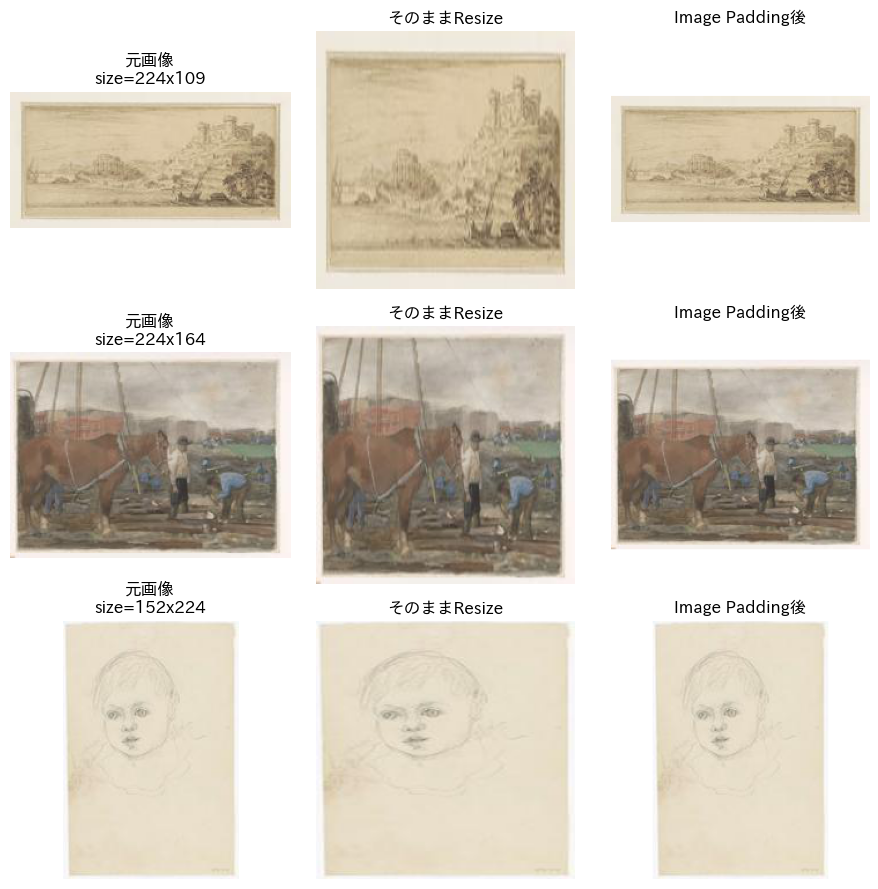

In [5]:
# Padding 前後の画像をざっくり確認するセル

from PIL import Image
import matplotlib.pyplot as plt

def pad_to_square(img: Image.Image, fill=(255, 255, 255)) -> Image.Image:
    """長辺に合わせて正方形にパディングする簡易関数"""
    w, h = img.size
    if w == h:
        return img
    side = max(w, h)
    canvas = Image.new("RGB", (side, side), color=fill)
    left = (side - w) // 2
    top = (side - h) // 2
    canvas.paste(img, (left, top))
    return canvas

img_size = 224  # モデル入力サイズに合わせる

# とりあえず上から数枚だけ見る（必要なら .sample() に変えてもOK）
n_show = 3
sample_df = train_df.head(n_show)

fig, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))

if n_show == 1:
    axes = [axes]  # 1枚のときでもループしやすくする

for i, (_, row) in enumerate(sample_df.iterrows()):
    object_id = str(row["object_id"])
    img_path = os.path.join(photo_dir, f"{object_id}.jpg")

    img = Image.open(img_path).convert("RGB")
    img_resize = img.resize((img_size, img_size))
    img_pad_resize = pad_to_square(img).resize((img_size, img_size))

    axes[i][0].imshow(img)
    axes[i][0].set_title(f"元画像\nsize={img.size[0]}x{img.size[1]}")
    axes[i][0].axis("off")

    axes[i][1].imshow(img_resize)
    axes[i][1].set_title("そのままResize")
    axes[i][1].axis("off")

    axes[i][2].imshow(img_pad_resize)
    axes[i][2].set_title("Image Padding後")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()


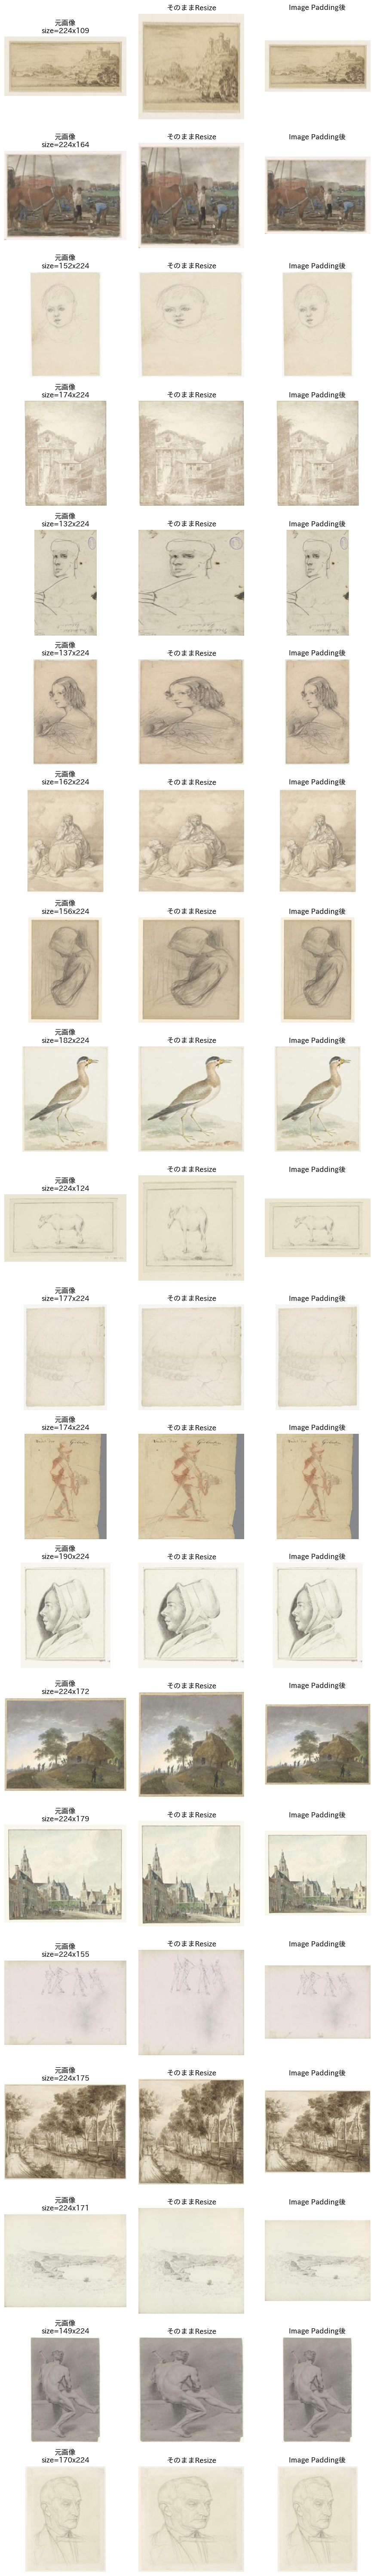

In [6]:

# とりあえず上から数枚だけ見る（必要なら .sample() に変えてもOK）
n_show = 20
sample_df = train_df.head(n_show)

fig, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))

if n_show == 1:
    axes = [axes]  # 1枚のときでもループしやすくする

for i, (_, row) in enumerate(sample_df.iterrows()):
    object_id = str(row["object_id"])
    img_path = os.path.join(photo_dir, f"{object_id}.jpg")

    img = Image.open(img_path).convert("RGB")
    img_resize = img.resize((img_size, img_size))
    img_pad_resize = pad_to_square(img).resize((img_size, img_size))

    axes[i][0].imshow(img)
    axes[i][0].set_title(f"元画像\nsize={img.size[0]}x{img.size[1]}")
    axes[i][0].axis("off")

    axes[i][1].imshow(img_resize)
    axes[i][1].set_title("そのままResize")
    axes[i][1].axis("off")

    axes[i][2].imshow(img_pad_resize)
    axes[i][2].set_title("Image Padding後")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()


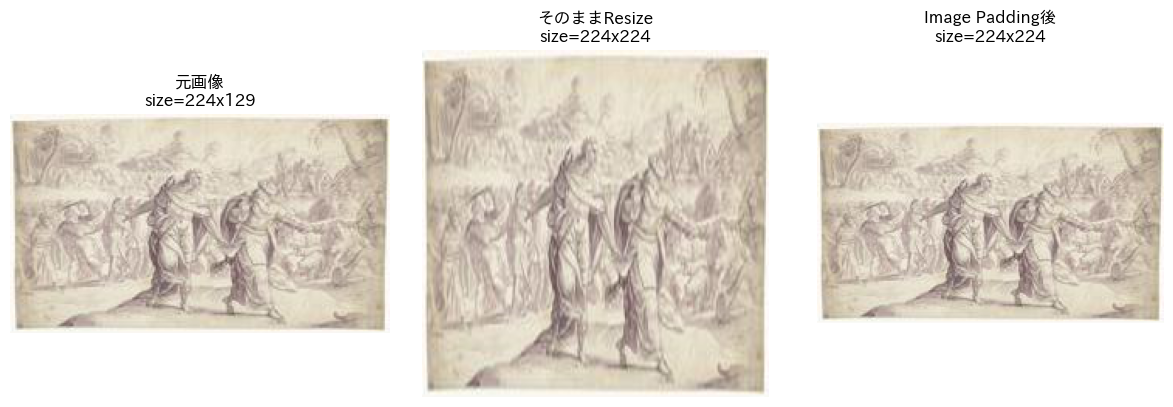

In [7]:
# Padding 前後の画像をざっくり確認するセル（縦横比が偏った画像を1枚探す）

from PIL import Image
import matplotlib.pyplot as plt

def pad_to_square(img: Image.Image, fill=(255, 255, 255)) -> Image.Image:
    """長辺に合わせて正方形にパディングする簡易関数"""
    w, h = img.size
    if w == h:
        return img

    side = max(w, h)
    canvas = Image.new("RGB", (side, side), color=fill)
    left = (side - w) // 2
    top = (side - h) // 2
    canvas.paste(img, (left, top))
    return canvas

img_size = 224  # モデル入力サイズ

# アスペクト比が偏っている画像を1枚探す（なければ先頭）
target_row = None
for _, row in train_df.sample(min(len(train_df), 200), random_state=0).iterrows():
    object_id = str(row["object_id"])
    img_path = os.path.join(photo_dir, f"{object_id}.jpg")
    try:
        img_tmp = Image.open(img_path).convert("RGB")
    except Exception:
        continue
    w, h = img_tmp.size
    ratio = max(w, h) / min(w, h)
    if ratio >= 1.3:  # 縦横比に偏りがあるものを採用
        target_row = row
        img = img_tmp
        break

# 見つからなければ先頭を使う
if target_row is None:
    row = train_df.iloc[0]
    object_id = str(row["object_id"])
    img_path = os.path.join(photo_dir, f"{object_id}.jpg")
    img = Image.open(img_path).convert("RGB")

w, h = img.size
img_resize = img.resize((img_size, img_size))
img_pad_resize = pad_to_square(img).resize((img_size, img_size))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img)
axes[0].set_title(f"元画像\nsize={w}x{h}")
axes[0].axis("off")

axes[1].imshow(img_resize)
axes[1].set_title(f"そのままResize\nsize={img_resize.size[0]}x{img_resize.size[1]}")
axes[1].axis("off")

axes[2].imshow(img_pad_resize)
axes[2].set_title(f"Image Padding後\nsize={img_pad_resize.size[0]}x{img_pad_resize.size[1]}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


元画像 size: (224, 109)
padding後 size: (224, 224)


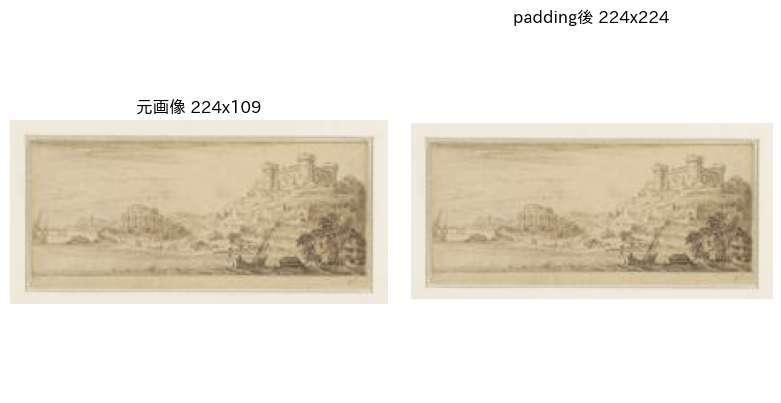

In [8]:
from PIL import Image

def pad_to_square(img: Image.Image, fill=(255, 255, 255)) -> Image.Image:
    """長辺に合わせて正方形にパディングする"""
    w, h = img.size
    if w == h:
        return img  # もともと正方形ならそのまま
    side = max(w, h)
    canvas = Image.new("RGB", (side, side), color=fill)
    left = (side - w) // 2
    top = (side - h) // 2
    canvas.paste(img, (left, top))
    return canvas

# 適当に1枚見る（必要なら index を変えてOK）
row = train_df.iloc[0]
object_id = str(row["object_id"])
img_path = os.path.join(photo_dir, f"{object_id}.jpg")

img = Image.open(img_path).convert("RGB")
padded = pad_to_square(img)

print("元画像 size:", img.size)         # (width, height)
print("padding後 size:", padded.size)  # ここが (N, N) になっているか確認

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title(f"元画像 {img.size[0]}x{img.size[1]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(padded)
plt.title(f"padding後 {padded.size[0]}x{padded.size[1]}")
plt.axis("off")

plt.tight_layout()
plt.show()


元画像 size: (224, 109)
そのままResize size: (224, 224)
padding後 size: (224, 224)
padding→Resize後 size: (224, 224)


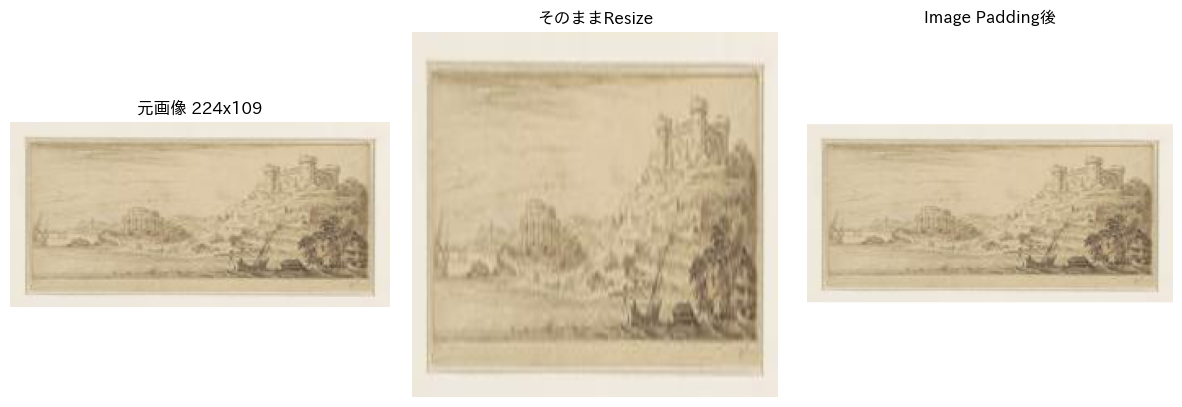

In [11]:
img_size = 224  # モデルの入力サイズ

row = train_df.iloc[0]
object_id = str(row["object_id"])
img_path = os.path.join(photo_dir, f"{object_id}.jpg")

img = Image.open(img_path).convert("RGB")
img_resize = img.resize((img_size, img_size))
img_pad = pad_to_square(img)
img_pad_resize = img_pad.resize((img_size, img_size))

print("元画像 size:", img.size)
print("そのままResize size:", img_resize.size)
print("padding後 size:", img_pad.size)
print("padding→Resize後 size:", img_pad_resize.size)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img)
axes[0].set_title(f"元画像 {img.size[0]}x{img.size[1]}")
axes[0].axis("off")

axes[1].imshow(img_resize)
axes[1].set_title("そのままResize")
axes[1].axis("off")

axes[2].imshow(img_pad_resize)
axes[2].set_title("Image Padding後")
axes[2].set_aspect('equal') 
axes[2].axis("off")

plt.tight_layout()
plt.show()



元画像 size: (224, 109)
padding後 size: (224, 224)
padding→Resize後 size: (224, 224)


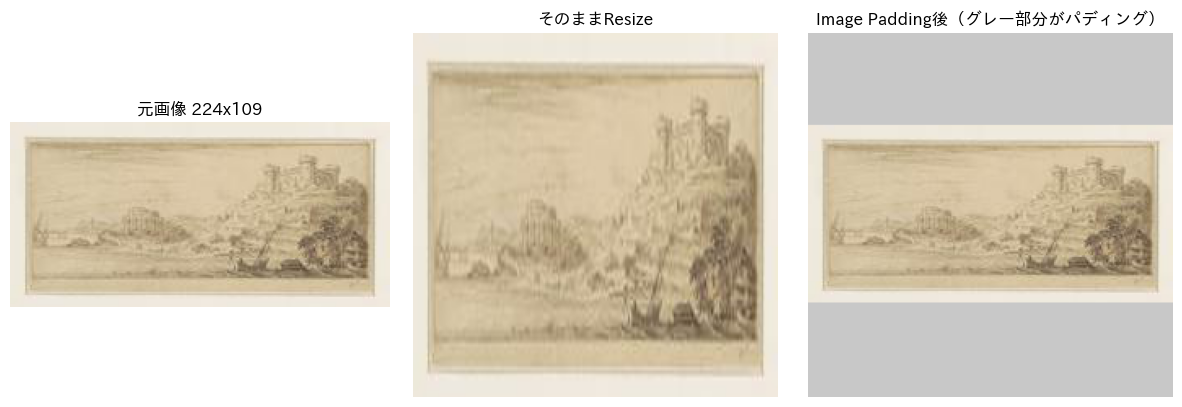

In [ ]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

def pad_to_square(img: Image.Image, fill=(200, 200, 200)) -> Image.Image:
    """
    長辺に合わせて正方形にパディングする。
    可視化のためにパディング色をグレーにしている。
    """
    w, h = img.size
    if w == h:
        return img
    side = max(w, h)
    canvas = Image.new("RGB", (side, side), color=fill)
    left = (side - w) // 2
    top = (side - h) // 2
    canvas.paste(img, (left, top))
    return canvas

img_size = 224

row = train_df.iloc[0]
object_id = str(row["object_id"])
img_path = os.path.join(photo_dir, f"{object_id}.jpg")

img = Image.open(img_path).convert("RGB")
img_resize = img.resize((img_size, img_size))
img_pad = pad_to_square(img, fill=(200, 200, 200))  # グレーでパディング
img_pad_resize = img_pad.resize((img_size, img_size))

print("元画像 size:", img.size)
print("padding後 size:", img_pad.size)
print("padding→Resize後 size:", img_pad_resize.size)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.patch.set_facecolor("white")  # 図の背景はそのまま白

axes[0].imshow(img)
axes[0].set_title(f"元画像 {img.size[0]}x{img.size[1]}")
axes[0].axis("off")

axes[1].imshow(img_resize)
axes[1].set_title("そのままResize")
axes[1].axis("off")

axes[2].imshow(img_pad_resize)
axes[2].set_title("Image Padding後（グレー部分がパディング）")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import os
from PIL import Image
import matplotlib.pyplot as plt

def pad_to_square(img: Image.Image, fill=(200, 200, 200)) -> Image.Image:
    w, h = img.size
    if w == h:
        return img
    side = max(w, h)
    canvas = Image.new("RGB", (side, side), color=fill)
    left = (side - w) // 2
    top = (side - h) // 2
    canvas.paste(img, (left, top))
    return canvas

img_size = 224

photo_dir = Path("input/photos")  # 例として
train_df = pd.read_csv(Path("input/train.csv"))

# 表示する画像数
num_images = 5
samples = train_df.sample(n=num_images, random_state=42)

fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
fig.patch.set_facecolor("white")

for i, (_, row) in enumerate(samples.iterrows()):
    object_id = str(row["object_id"])
    img_path = photo_dir / f"{object_id}.jpg"
    if not img_path.exists():
        print(f"WARNING: {img_path} が存在しません")
        continue

    img = Image.open(img_path).convert("RGB")
    img_resize = img.resize((img_size, img_size))
    img_pad = pad_to_square(img, fill=(200, 200, 200))
    img_pad_resize = img_pad.resize((img_size, img_size))

    ax0, ax1, ax2 = axes[i]
    ax0.imshow(img)
    ax0.set_title(f"元画像 {img.size[0]}×{img.size[1]}")
    ax0.axis("off")

    ax1.imshow(img_resize)
    ax1.set_title("そのままResize")
    ax1.axis("off")

    ax2.imshow(img_pad_resize)
    ax2.set_title("Padding後→Resize")
    ax2.axis("off")

plt.tight_layout()
plt.show()
